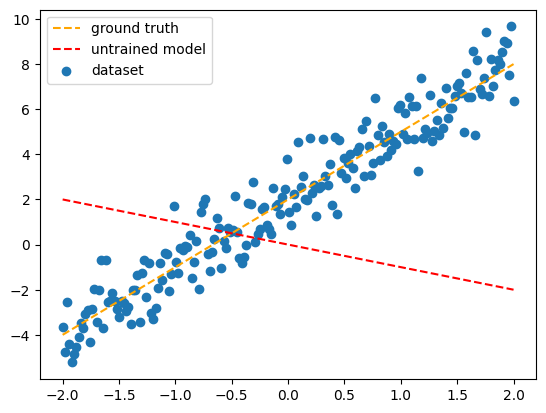

In [301]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np

class Modello(tf.Module):
    def __init__(self, **kwargs):
        super().__init__(**kwargs)
        self._w = tf.Variable(-1.)
        self._b = tf.Variable(0.)

        self.weights = [self._w]
        self.biases = [self._b]
        self.losses = []

    def __call__(self, x):
        return self._w * x + self._b
    
    # Loss = RMS
    def loss(self, y_true, y_pred):
        return tf.reduce_mean(tf.square(y_true - y_pred))
    
    def get_losses(self):
        return self.losses
    
    # Implementa un ciclo di training: forward pass + backpropagation
    def train(self, y_true, x, learning_rate = .1):
        with tf.GradientTape() as t:
            current_loss = self.loss(y_true, self.__call__(x))

            dw, db = t.gradient(current_loss, [self._w, self._b])

            self._w.assign_sub(dw * learning_rate)
            self._b.assign_sub(db * learning_rate)

    # Implementa un loop di training per un numero specificato di epoche
    def training_loop(self, x, y_true, learning_rate = .1, epochs = 10):
        self.losses = []
        for epoch in range(epochs):
            self.train(y_true, x, learning_rate)

            current_loss = self.loss(y_true, self.__call__(x))

            self.weights.append(self._w)
            self.biases.append(self._b)
            self.losses.append(current_loss)

            print(f"\nEpoch {epoch}:\n\t Loss: {current_loss}")


# Ground Truth
def f(x):
    return 3. * x + 2.


model = Modello()

x = tf.linspace(-2,2, 200)
x = tf.cast(x, tf.float32)

y = f(x) + tf.random.normal(shape=x.shape)


y_untrained = model(x)

plt.plot(x, f(x),'--' ,label="ground truth", color="orange")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.scatter(x, y, label="dataset")
plt.legend()

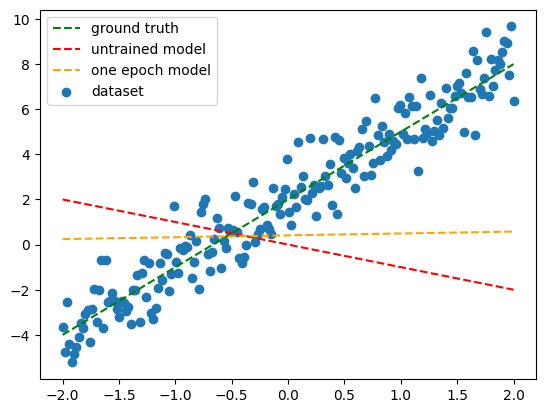

In [302]:
model.train(y,x)
y_first_train = model(x)

plt.plot(x, f(x),'--' ,label="ground truth", color="green")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.plot(x, y_first_train,'--' ,label="one epoch model", color="orange")
plt.scatter(x, y, label="dataset")
plt.legend()


Epoch 0:
	 Loss: 8.883476257324219

Epoch 1:
	 Loss: 5.369998931884766

Epoch 2:
	 Loss: 3.4285571575164795

Epoch 3:
	 Loss: 2.3500254154205322

Epoch 4:
	 Loss: 1.7473127841949463

Epoch 5:
	 Loss: 1.4083143472671509

Epoch 6:
	 Loss: 1.216306447982788

Epoch 7:
	 Loss: 1.1067415475845337

Epoch 8:
	 Loss: 1.0437310934066772

Epoch 9:
	 Loss: 1.0072005987167358


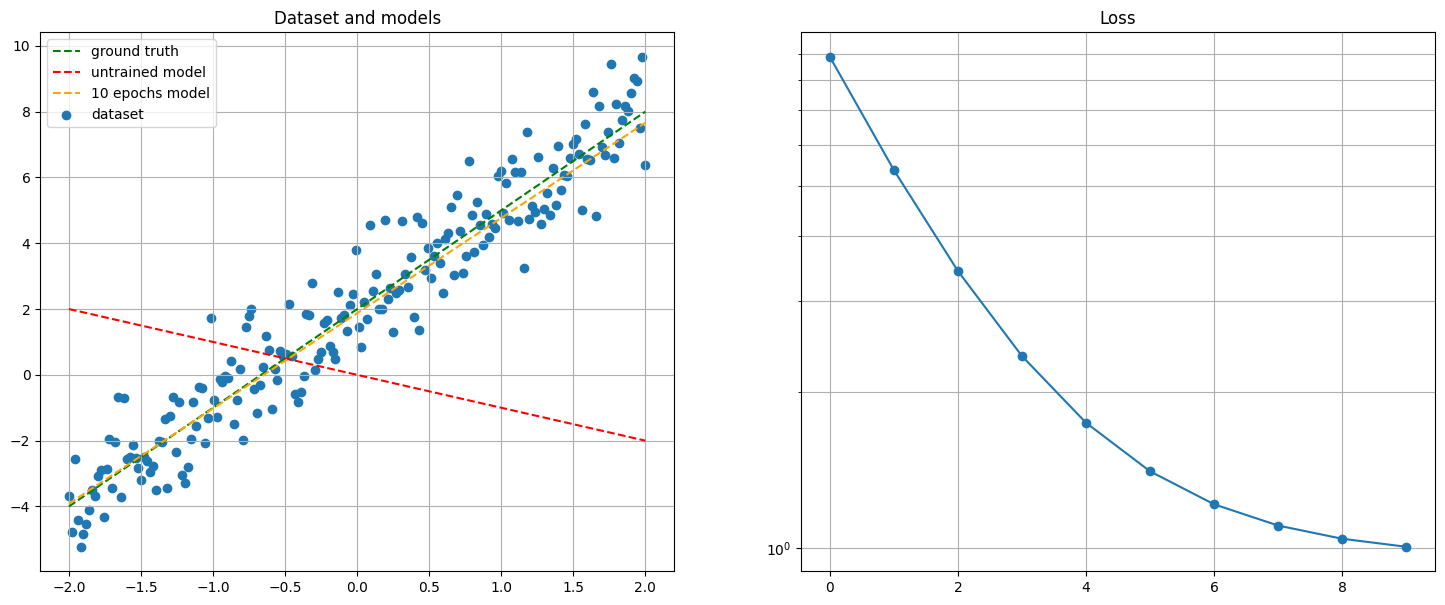

In [303]:
epochs = 10
model.training_loop(x,y, epochs=10)
y_trained = model(x)


fig = plt.figure(figsize=(18,7))
a = plt.subplot(1,2,1)
plt.grid(True, 'both')
plt.title('Dataset and models')
plt.plot(x, f(x),'--' ,label="ground truth", color="green")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.plot(x, y_trained,'--' ,label="10 epochs model", color="orange")
plt.scatter(x, y, label="dataset")
plt.legend()

a = plt.subplot(1,2,2)
plt.semilogy()
plt.title('Loss')
plt.grid(True, 'both', 'both')
plt.plot(range(epochs), model.get_losses(), '-o')


Implementazione con keras API

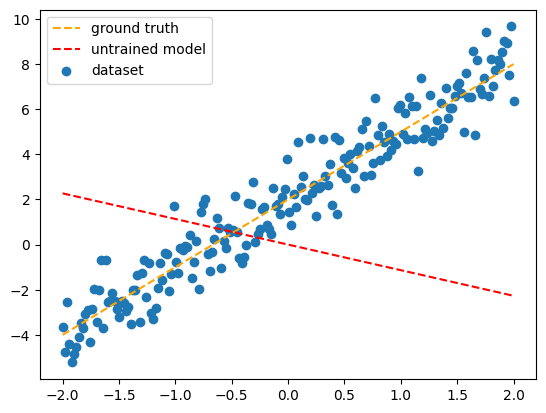

In [304]:
model2 = tf.keras.Sequential()

model2.add(tf.keras.layers.Input(shape=(1,)))
model2.add(tf.keras.layers.Dense(1))

y_untrained = model2(x)

plt.plot(x, f(x),'--' ,label="ground truth", color="orange")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.scatter(x, y, label="dataset")
plt.legend()


In [305]:
model2.compile(optimizer=tf.keras.optimizers.SGD(learning_rate=.1), 
                    loss = tf.keras.losses.MeanSquaredError)


class LossHistory(tf.keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.losses = []

    def on_batch_end(self, batch, logs={}):
        self.losses.append(logs.get('loss'))

history = LossHistory()
model2.fit(x, y, epochs=epochs, batch_size=len(x), verbose=0, callbacks=[history])

print(history.losses)


[28.42700958251953, 16.066680908203125, 9.307528495788574, 5.596380710601807, 3.5494115352630615, 2.4145445823669434, 1.7817567586898804, 1.426702618598938, 1.2261228561401367, 1.1119821071624756]


/var/folders/g_/3dpvp_h12blfrzxnvvfj2q1m0000gn/T/ipykernel_3371/2231955046.py:15: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


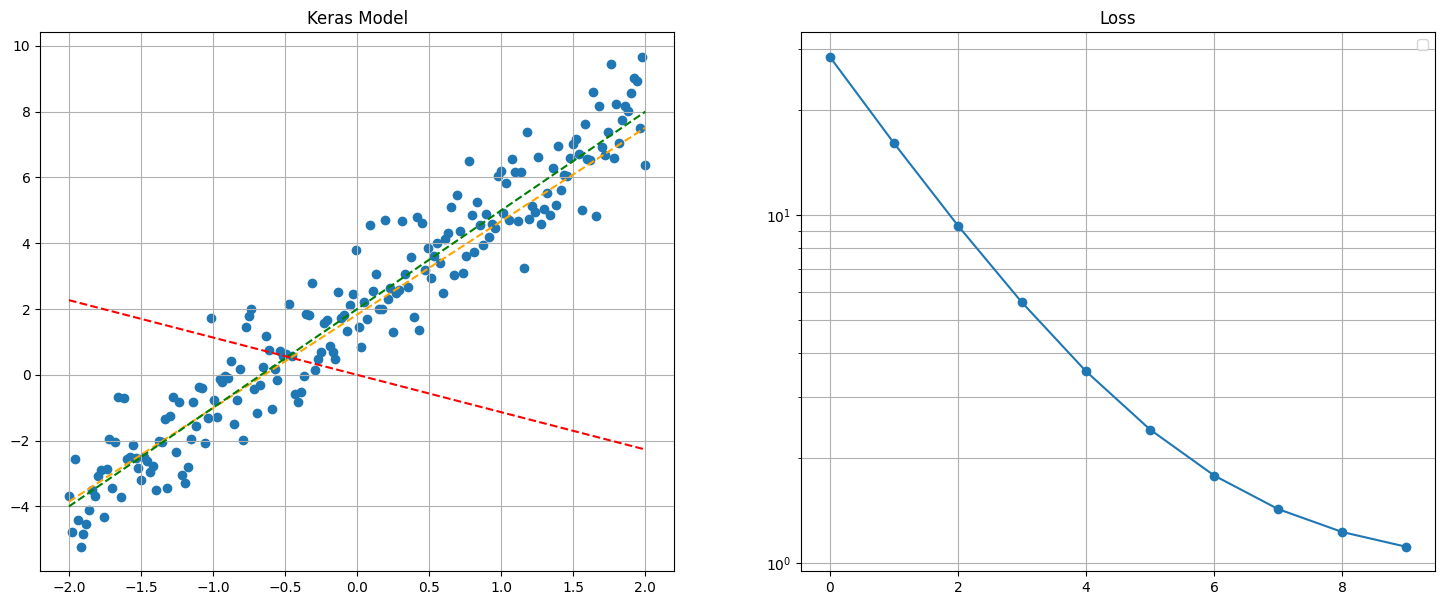

In [306]:
fig = plt.figure(figsize=(18,7))
a = plt.subplot(1,2,1)
plt.plot(x, model2(x), '--', label='Keras Model 10 epochs', color='orange')
plt.plot(x, f(x),'--' ,label="ground truth", color="green")
plt.plot(x, y_untrained,'--' ,label="untrained model", color="red")
plt.scatter(x, y, label="dataset")
plt.title('Keras Model')
plt.grid('both')

a = plt.subplot(1,2,2)
plt.semilogy()
plt.title('Loss')
plt.grid(True, 'both', 'both')
plt.plot(range(epochs), history.losses, '-o')
plt.legend()
